In [1]:
import pandas as pd

df = pd.read_csv("world_cup_last_50_years.csv")

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 832 entries, 0 to 831
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   year        832 non-null    int64
 1   date        832 non-null    str  
 2   stage       832 non-null    str  
 3   home_team   832 non-null    str  
 4   away_team   832 non-null    str  
 5   home_goals  832 non-null    int64
 6   away_goals  832 non-null    int64
 7   winner      832 non-null    str  
 8   match_id    832 non-null    int64
dtypes: int64(4), str(5)
memory usage: 58.6 KB


,year,home_goals,away_goals,match_id
count,832.000000,832.000000,832.000000,832.000000
mean,1998.000000,1.137019,1.090144,416.500000
std,14.975632,0.859841,0.880487,240.322006
min,1974.000000,0.000000,0.000000,1.000000
25%,1986.000000,1.000000,0.000000,208.750000
50%,1998.000000,1.000000,1.000000,416.500000
75%,2010.000000,2.000000,2.000000,624.250000
max,2022.000000,3.000000,3.000000,832.000000


In [2]:
# remove null values
df = df.dropna()

# convert date
df['date'] = pd.to_datetime(df['date'])

# standardize team names
df['home_team'] = df['home_team'].str.strip()
df['away_team'] = df['away_team'].str.strip()

In [4]:
print(df.columns)

Index(['year', 'date', 'stage', 'home_team', 'away_team', 'home_goals',
       'away_goals', 'winner', 'match_id'],
      dtype='str')


In [5]:
import numpy as np

df['goal_diff'] = df['home_goals'] - df['away_goals']

df['result'] = np.where(df['goal_diff'] > 0, 'Win',
                np.where(df['goal_diff'] < 0, 'Loss', 'Draw'))

In [6]:
df[['home_team','away_team','home_goals','away_goals','goal_diff','result']].head()

,home_team,away_team,home_goals,away_goals,goal_diff,result
0,South Korea,Sweden,0,0,0,Draw
1,Ghana,Switzerland,2,0,2,Win
2,Sweden,Saudi Arabia,2,0,2,Win
3,Cameroon,Uruguay,2,1,1,Win
4,Nigeria,Japan,2,1,1,Win


In [8]:
!pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 4.2 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.3 MB 4.2 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.3 MB 4.3 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.3 MB 4.3 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.3 MB 4.4 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.3 MB 4.4 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.3 MB 4.5 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 4.5 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.3 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 4.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.3 MB 4.2 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import matplotlib.pyplot as plt
print("Matplotlib working ✅")

Matplotlib working ✅


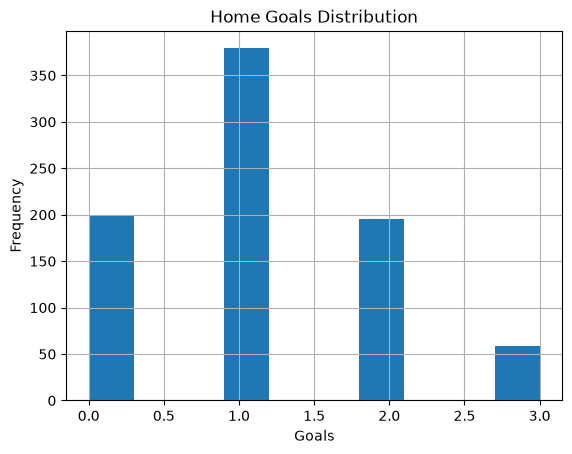

home_team
Nigeria        1.500000
Spain          1.419355
Cameroon       1.285714
England        1.277778
Sweden         1.269231
Croatia        1.258065
Morocco        1.230769
Uruguay        1.217391
Ghana          1.214286
Switzerland    1.212121
Name: home_goals, dtype: float64

In [10]:
import matplotlib.pyplot as plt

# goals distribution
df['home_goals'].hist()
plt.title("Home Goals Distribution")
plt.xlabel("Goals")
plt.ylabel("Frequency")
plt.show()

# top scoring teams
df.groupby('home_team')['home_goals'].mean().sort_values(ascending=False).head(10)

In [11]:
team_stats = df.groupby('home_team').agg({
    'home_goals': 'mean',
    'away_goals': 'mean'
}).reset_index()

team_stats.columns = ['team', 'avg_goals_scored_home', 'avg_goals_conceded_home']

In [13]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.2 MB 29.4 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 25.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------- ----------------------------- 9.2/36.6 MB 57.1 MB/s eta 0:00:01
   -------------- ------------------------- 13.1/36.6 MB 34.3 MB/s eta 0:00:01
   ----------------- ---------------------- 16.0/36.6 MB 26.5 MB/s eta 0:00:01
   ------------------ --------------------- 17.3/36.6 MB 22.7 MB/s eta 0:00:01
   --------------------- ------------------ 19.7/36.6 MB 20.4 MB/s eta 0:00:01
   ------------------------ --------------- 22.8/36.6 MB 18.5 MB/s eta 0:00:01
   --------------------------- ------------ 24.9/36.6 MB 17.7 MB/s eta 0:00:01
   ---------------------------- ----------- 26.0/36.6 MB 16.1 MB/s eta 0:00:01
   -------------------------------- ------- 29.6/36.6 MB 16.1 MB/s eta 0:00:


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Features (use correct columns)
X = df[['home_goals', 'away_goals']]

# Convert result to numeric
y = df['result'].map({'Win': 1, 'Loss': 0, 'Draw': 2})

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Accuracy
print(model.score(X_test, y_test))

1.0


In [15]:
df.to_csv("fifa_cleaned.csv", index=False)

In [16]:

!pip install streamlit

   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.3 MB 4.2 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/10.3 MB 4.7 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/10.3 MB 5.2 MB/s eta 0:00:02
   ------------------ --------------------- 4.7/10.3 MB 6.3 MB/s eta 0:00:01
   --------------------------- ------------ 7.1/10.3 MB 7.2 MB/s eta 0:00:01
   ---------------------------------------  10.2/10.3 MB 8.6 MB/s eta 0:00:01
   ---------------------------------------- 10.3/10.3 MB 8.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/797.6 kB ? eta -:--:--
   --------------------------------------- 797.6/797.6 kB 11.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/27.4 MB ? eta -:--:--
   ------ --------------------------------- 4.2/27.4 MB 19.4 MB/s eta 0:00:02
   ------------- -------------------------- 9.4/27.4 MB 22.6 MB/s eta 0:00:01
   ---------


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
